# IRONKAGGLE NOTEBOOK - KING COUNTRY HOUSES
FELICIU & ENRIQUE
 


## IMPORTING LIBRARIES/FUNCTIONS

In [283]:
# =======================
# Core libraries
# =======================
import numpy as np
import pandas as pd

# =======================
# Visualization
# =======================
import matplotlib.pyplot as plt
import seaborn as sns

# =======================
# Geospatial
# =======================
import geopandas as gpd
import contextily as ctx

# =======================
# Machine Learning - Model Selection
# =======================
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV

# =======================
# Machine Learning - Preprocessing
# =======================
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# =======================
# Machine Learning - Models
# =======================
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.cluster import KMeans
from lightgbm import LGBMRegressor

# =======================
# Machine Learning - Metrics
# =======================
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# =======================
# Explainability
# =======================
import shap

## INTRODUCING THE DATA

In [284]:
df = pd.read_csv("Ironkaggle/king_ country_ houses_aa.csv")

In [285]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [286]:
df.keys()

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='str')

In [287]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [288]:
df.dtypes

id                 int64
date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [289]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [290]:
df.nunique()

id               21436
date               372
price             4028
bedrooms            13
bathrooms           30
sqft_living       1038
sqft_lot          9782
floors               6
waterfront           2
view                 5
condition            5
grade               12
sqft_above         946
sqft_basement      306
yr_built           116
yr_renovated        70
zipcode             70
lat               5034
long               752
sqft_living15      777
sqft_lot15        8689
dtype: int64

In [291]:
df.isna().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

## EDA

## Classification

In [292]:
target = "price"
y = df[target]


In [293]:
# id --> control digit? Correlated with date? Just random number?
# date --> date of the sale, we ensure datetime utc format. Study if there is a correlation between date and price (seasonality, trends, etc).
# zipcode --> categorical variable, we will one-hot encode it, 70 different zipcodes (adding 70 columns).

"""
lat and long --> zip code is more useful than latitude and longitude, but we can also create a new feature
with the distance to the city center (we can use the coordinates of the city center as reference) or to water bodies.
"""

cat_features = [
    "waterfront",
    "view",
    "zipcode",
    "condition",
    "grade",
    "floors",
    "bathrooms",
    "bedrooms",
]

In [294]:
# yr_built and yr_renovated --> transforming them into years since built/renovated, which will probably have a negative correlation with the price.
# yr_renovated --> 0 means never renovated, we can create a new column with a boolean value (renovated or not) as categorical variable.

num_features = [
    "sqft_living",
    "sqft_lot",
    "sqft_above",
    "sqft_basement",
    "sqft_living15",
    "sqft_lot15",
    "yr_built",
    "yr_renovated",
]

In [295]:
len(df.columns) == len(cat_features) + len(
    num_features
) + 5  # 5 columns that we are not going to use as features (id, date, lat, long, price)

True

In [296]:
df_cat = df[cat_features]

print(df_cat.nunique())

waterfront     2
view           5
zipcode       70
condition      5
grade         12
floors         6
bathrooms     30
bedrooms      13
dtype: int64


In [297]:
df_num = df[num_features]

print(df_num.describe())

        sqft_living      sqft_lot    sqft_above  sqft_basement  sqft_living15  \
count  21613.000000  2.161300e+04  21613.000000   21613.000000   21613.000000   
mean    2079.899736  1.510697e+04   1788.390691     291.509045    1986.552492   
std      918.440897  4.142051e+04    828.090978     442.575043     685.391304   
min      290.000000  5.200000e+02    290.000000       0.000000     399.000000   
25%     1427.000000  5.040000e+03   1190.000000       0.000000    1490.000000   
50%     1910.000000  7.618000e+03   1560.000000       0.000000    1840.000000   
75%     2550.000000  1.068800e+04   2210.000000     560.000000    2360.000000   
max    13540.000000  1.651359e+06   9410.000000    4820.000000    6210.000000   

          sqft_lot15      yr_built  yr_renovated  
count   21613.000000  21613.000000  21613.000000  
mean    12768.455652   1971.005136     84.402258  
std     27304.179631     29.373411    401.679240  
min       651.000000   1900.000000      0.000000  
25%      5100.0

## Processing

In [298]:
df["date"] = pd.to_datetime(df["date"], utc=True)
df["date"].dtype

datetime64[us, UTC]

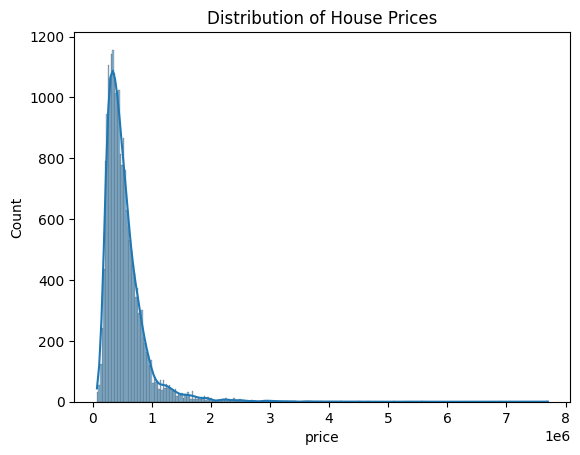

'\nIs not normal distribution is right-skewed distribution (will have to apply log transformation)\n'

In [299]:
# The PRICE distributin

sns.histplot(df["price"], kde=True)
plt.title("Distribution of House Prices")
plt.show()

"""
Is not normal distribution is right-skewed distribution (will have to apply log transformation)
"""

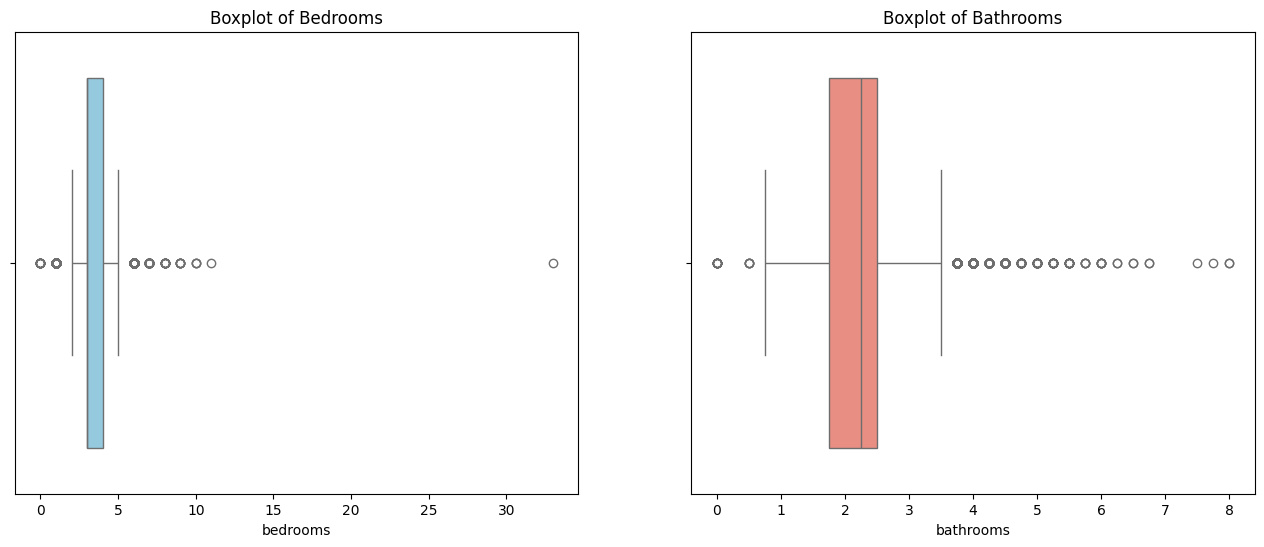

'\nOne house has 30 + bedrooms, is an outlier which has to be removed, some of them has more than 10\n'

In [300]:
plt.figure(figsize=(16, 6))

# Plot 1: Bedrooms
plt.subplot(1, 2, 1)
sns.boxplot(x=df["bedrooms"], color="skyblue")
plt.title("Boxplot of Bedrooms")

# Plot 2: Bathrooms
plt.subplot(1, 2, 2)
sns.boxplot(x=df["bathrooms"], color="salmon")
plt.title("Boxplot of Bathrooms")

plt.show()

"""
One house has 30 + bedrooms, is an outlier which has to be removed, some of them has more than 10
"""

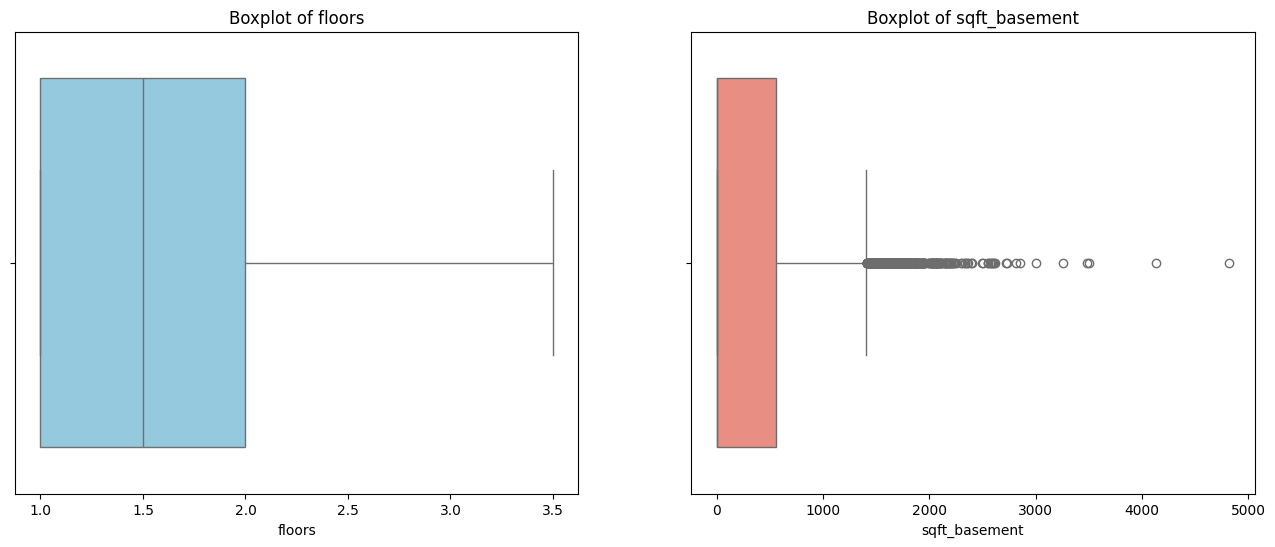

'\nBasmet square we have big numbers, couple of them are above 3000 sqft\n'

In [301]:
plt.figure(figsize=(16, 6))

# Plot 1: Foloors
plt.subplot(1, 2, 1)
sns.boxplot(x=df["floors"], color="skyblue")
plt.title("Boxplot of floors")

# Plot 2: Bathrooms
plt.subplot(1, 2, 2)
sns.boxplot(x=df["sqft_basement"], color="salmon")
plt.title("Boxplot of sqft_basement")

plt.show()

"""
Basmet square we have big numbers, couple of them are above 3000 sqft
"""

In [302]:
# Regarding the ouliers trying to see if the houses wihch got more than....5 bedroom are afecting the price, bathrooms number, sqft for: living, basement, above, lot, etc.
# Locate the extreme outlier
extreme_bedrooms = df[df["bedrooms"] >= 10]
print("Houses with more than 10 bedrooms:")
print(
    extreme_bedrooms[
        [
            "price",
            "bedrooms",
            "bathrooms",
            "sqft_living",
            "sqft_lot",
            "sqft_above",
            "sqft_basement",
            "floors",
        ]
    ]
)

Houses with more than 10 bedrooms:
           price  bedrooms  bathrooms  sqft_living  sqft_lot  sqft_above  \
8757    520000.0        11       3.00         3000      4960        2400   
13314  1148000.0        10       5.25         4590     10920        2500   
15161   650000.0        10       2.00         3610     11914        3010   
15870   640000.0        33       1.75         1620      6000        1040   
19254   660000.0        10       3.00         2920      3745        1860   

       sqft_basement  floors  
8757             600     2.0  
13314           2090     1.0  
15161            600     2.0  
15870            580     1.0  
19254           1060     2.0  


In [303]:
df_cleaned = df[df["bedrooms"] < 10]

# For better representation of the price distribution, we can apply a logarithmic transformation to the price variable. This can help to reduce the skewness and make the distribution more normal, which is often beneficial for modeling purposes.
df_cleaned["price_log"]=np.log(df_cleaned["price"])

### Seasonality study

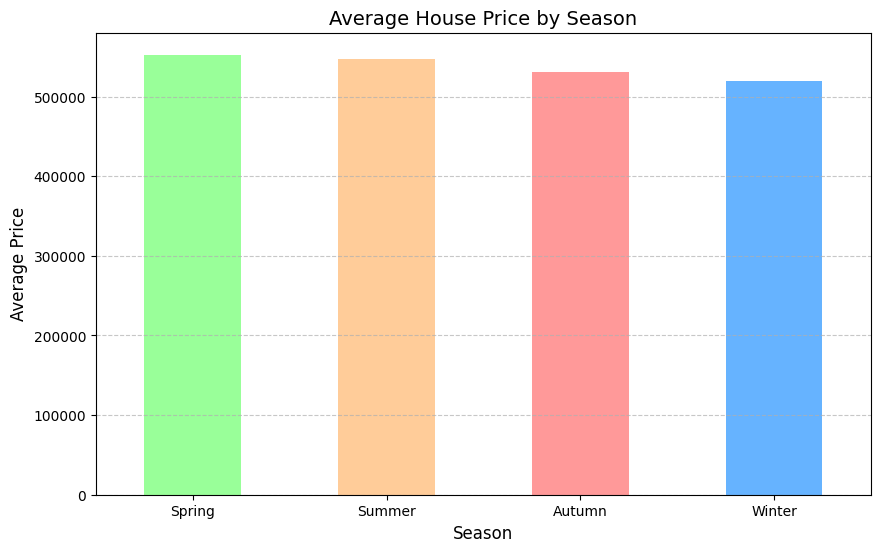

Average Spring Price: $552,603.24
Average Winter Price: $519,183.17
---
Difference: $33,420.08
Percentage Increase in Spring: 6.44%


'\nThere is just a small difference of 6.44% between selling the house in winter and selling the house in spring\n'

In [304]:
# 1. Ensure the column is a proper datetime object
df_cleaned["date"] = pd.to_datetime(df["date"])

# 2. Strip the Time (Keep only Year-Month-Day)
df_cleaned["date_only"] = df_cleaned["date"].dt.date


# 3. Create a 'Season' column based on the month
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"


df_cleaned["season"] = df_cleaned["date"].dt.month.apply(get_season)


# Calculate average price per season
seasonal_data = (
    df_cleaned.groupby("season")["price"].mean().reindex(["Spring", "Summer", "Autumn", "Winter"])
)

# Plotting
plt.figure(figsize=(10, 6))
seasonal_data.plot(kind="bar", color=["#99ff99", "#ffcc99", "#ff9999", "#66b3ff"])

plt.title("Average House Price by Season", fontsize=14)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Average Price", fontsize=12)
plt.xticks(rotation=0)  # Keeps the labels horizontal
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

# 1. Calculate the average price for each season
avg_prices = df_cleaned.groupby("season")["price"].mean()

spring_price = avg_prices["Spring"]
winter_price = avg_prices["Winter"]

# 2. Calculate the differences
price_diff = spring_price - winter_price
percentage_diff = (price_diff / winter_price) * 100

print(f"Average Spring Price: ${spring_price:,.2f}")
print(f"Average Winter Price: ${winter_price:,.2f}")
print(f"---")
print(f"Difference: ${price_diff:,.2f}")
print(f"Percentage Increase in Spring: {percentage_diff:.2f}%")

"""
There is just a small difference of 6.44% between selling the house in winter and selling the house in spring
"""

### Correlation matrix

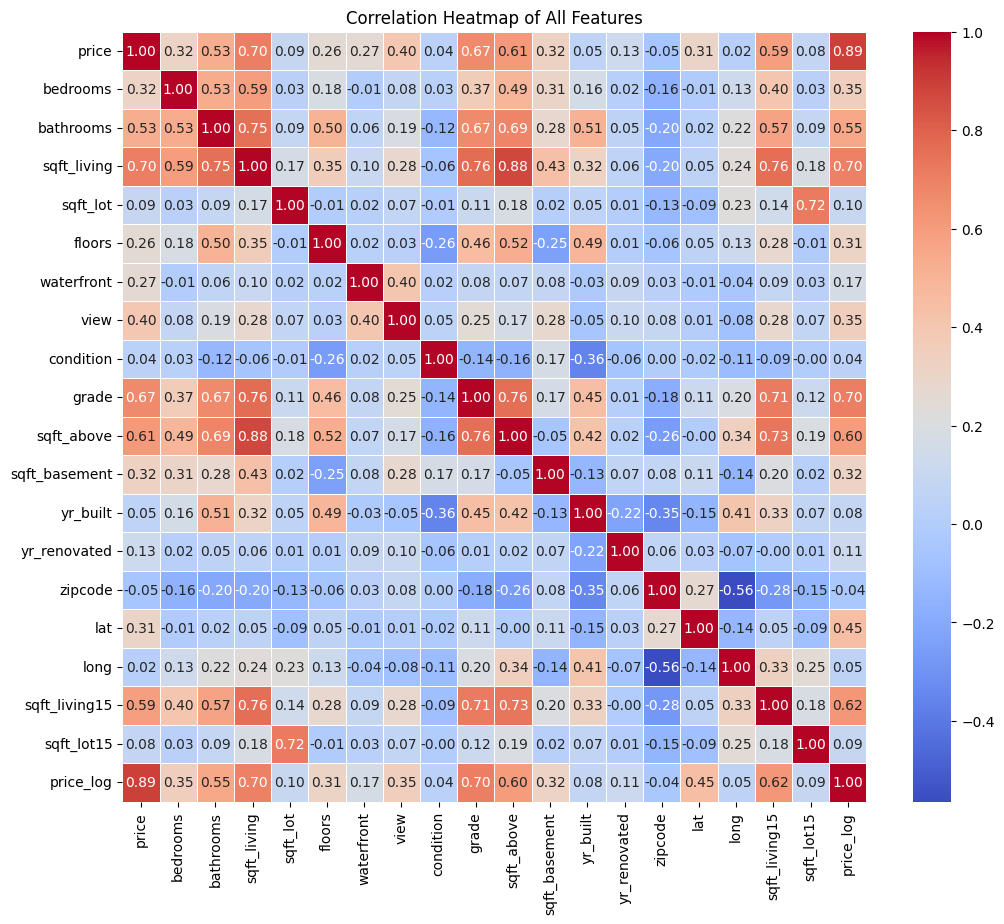

In [305]:
# 1. Calculate the correlation matrix
# We use .select_dtypes('number') to ignore text/date columns
df_cleaned = df_cleaned.drop("id", axis=1, errors="ignore")
corr_matrix = df_cleaned.select_dtypes("number").corr()

# 2. Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# 3. Create the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,  # Show the numeric values in the cells
    fmt=".2f",  # Round to 2 decimal places
    cmap="coolwarm",  # Red for positive, Blue for negative
    linewidths=0.5,
)

plt.title("Correlation Heatmap of All Features")
plt.show()

##### KEEP:
    sqft_living (0.70): The strongest physical predictor.
    grade (0.67): High-quality construction significantly bumps price.
    bathrooms (0.53): A reliable indicator of house size/luxury.
    view (0.40): A good secondary indicator of value.
#### SOMETHING INTRESTING:
    yr_built (0.05): The raw year doesn't correlate well because an old house could be a "historic gem" or a "fixer-upper."
    yr_renovated (0.13): Most values are zero.
    Recommendation: Instead of dropping them, combine them! Create an age feature (2026 - yr_built) and an is_renovated (1 or 0) feature.

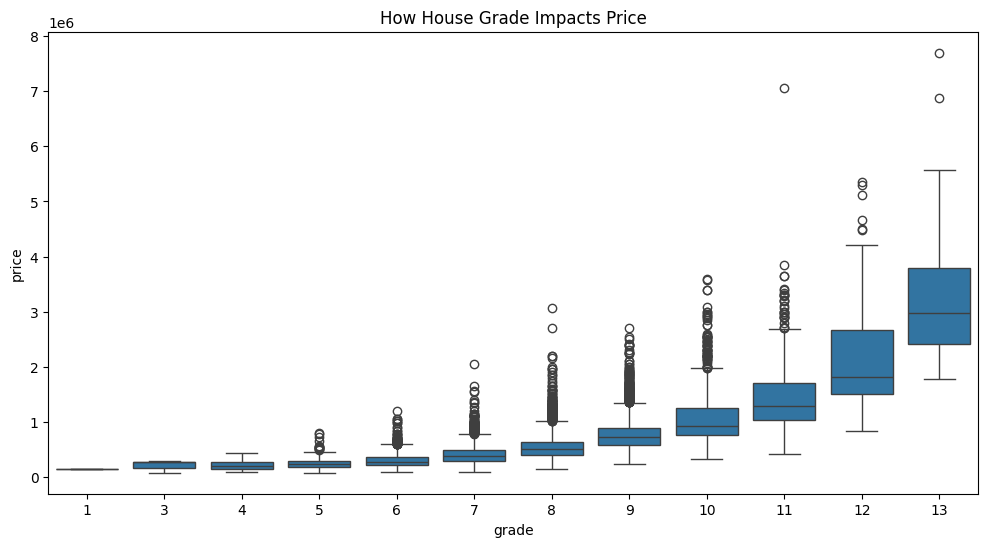

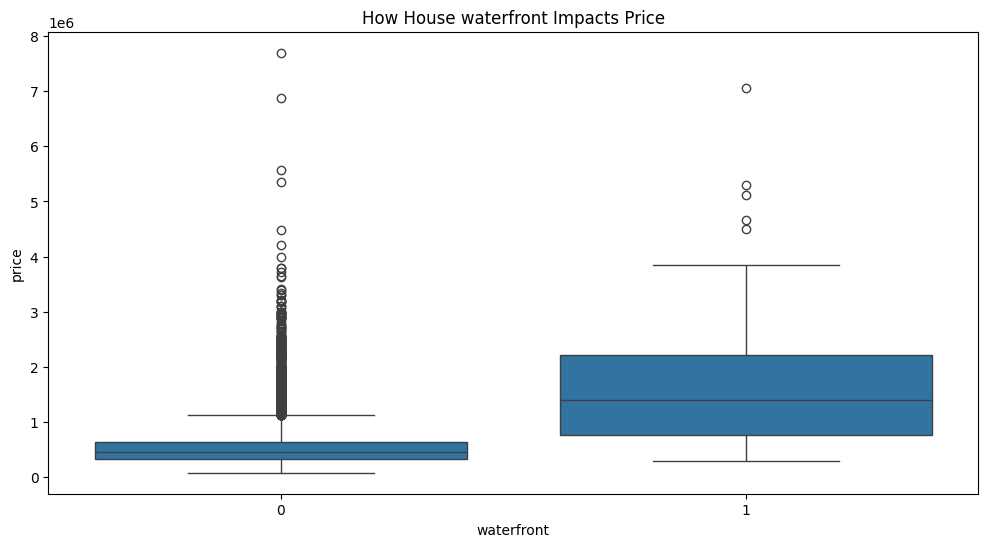

"\nHow House Grade Impacts Price:\nExponential Growth: Price doesn't just increase linearly with grade—it curves upward. Moving from a Grade 7 to a Grade 8 \nhas a smaller price jump than moving from Grade 11 to Grade 12.\n\nHow Waterfront Impacts Price:\nThe median price for waterfront (1) homes is significantly higher than the highest non-outlier prices for standard homes.\nEven without a waterfront view (the 0 category), there are many homes in the $3M–$7M range. \nThis suggests that while waterfront is a huge boost, location/size can still drive prices to the extreme on their own.\n\n"

In [306]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="grade", y="price", data=df)
plt.title("How House Grade Impacts Price")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x="waterfront", y="price", data=df)
plt.title("How House waterfront Impacts Price")
plt.show()
"""
How House Grade Impacts Price:
Exponential Growth: Price doesn't just increase linearly with grade—it curves upward. Moving from a Grade 7 to a Grade 8 
has a smaller price jump than moving from Grade 11 to Grade 12.

How Waterfront Impacts Price:
The median price for waterfront (1) homes is significantly higher than the highest non-outlier prices for standard homes.
Even without a waterfront view (the 0 category), there are many homes in the $3M–$7M range. 
This suggests that while waterfront is a huge boost, location/size can still drive prices to the extreme on their own.

"""

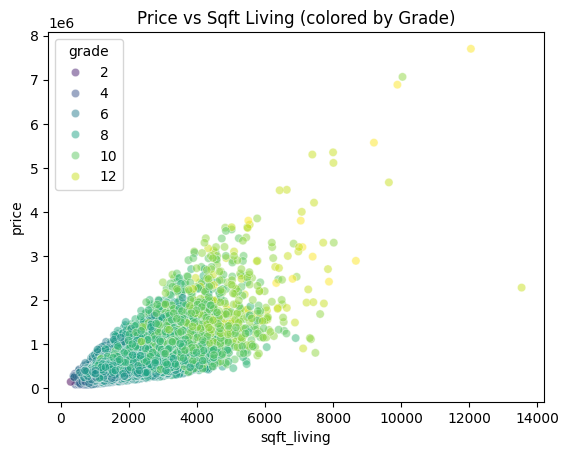

In [307]:
# Check how living space relates to grade and price simultaneously
sns.scatterplot(data=df, x="sqft_living", y="price", hue="grade", palette="viridis", alpha=0.5)
plt.title("Price vs Sqft Living (colored by Grade)")
plt.show()

## GEOSPACIAL STUDY - SIDE MODELLING

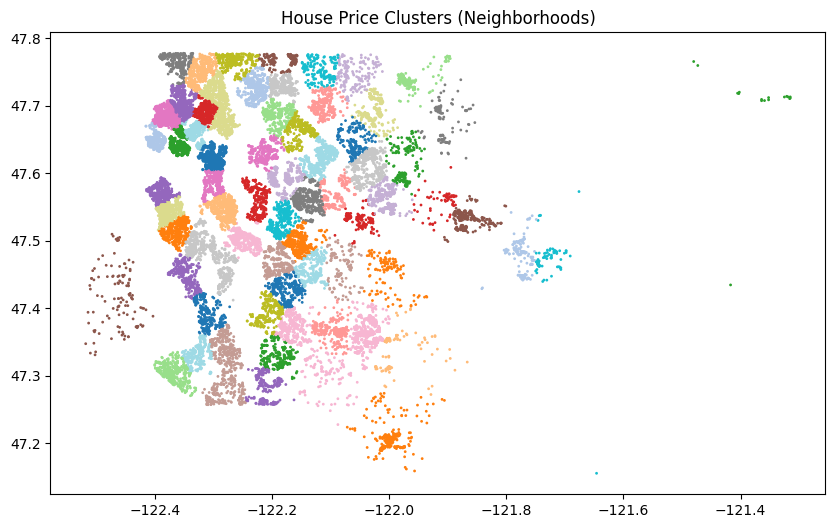

In [308]:
"""
Regarding the lat and long, we can take the Seattle city center and calculate the distance for each house based on distance we can calcualte the price
For new created column "neighborhood_group" use Random Forest / XGBoost
"""

# Coordinates of the city center (example: Seattle)
center_lat, center_long = 47.62, -122.33

# Simple Euclidean distance (works for small city areas)
df_cleaned["dist_to_center"] = np.sqrt((df_cleaned["lat"] - center_lat) ** 2 + (df_cleaned["long"] - center_long) ** 2)

# Create 70 "price neighborhoods" based on location. We will compare with the zipcodes.
price_neighborhoods_number=70
coords = df_cleaned[["lat", "long"]]
# 2. Create 70 clusters (representing 70 logical neighborhoods)
kmeans = KMeans(n_clusters=price_neighborhoods_number, random_state=13)
df_cleaned["neighborhood_group"] = kmeans.fit_predict(coords)


# 3. Visualize the clusters to see the "Zones"
plt.figure(figsize=(10, 6))
plt.scatter(
    df_cleaned["long"], df_cleaned["lat"], c=df_cleaned["neighborhood_group"], cmap="tab20", s=1
)
plt.title("House Price Clusters (Neighborhoods)")
plt.show()

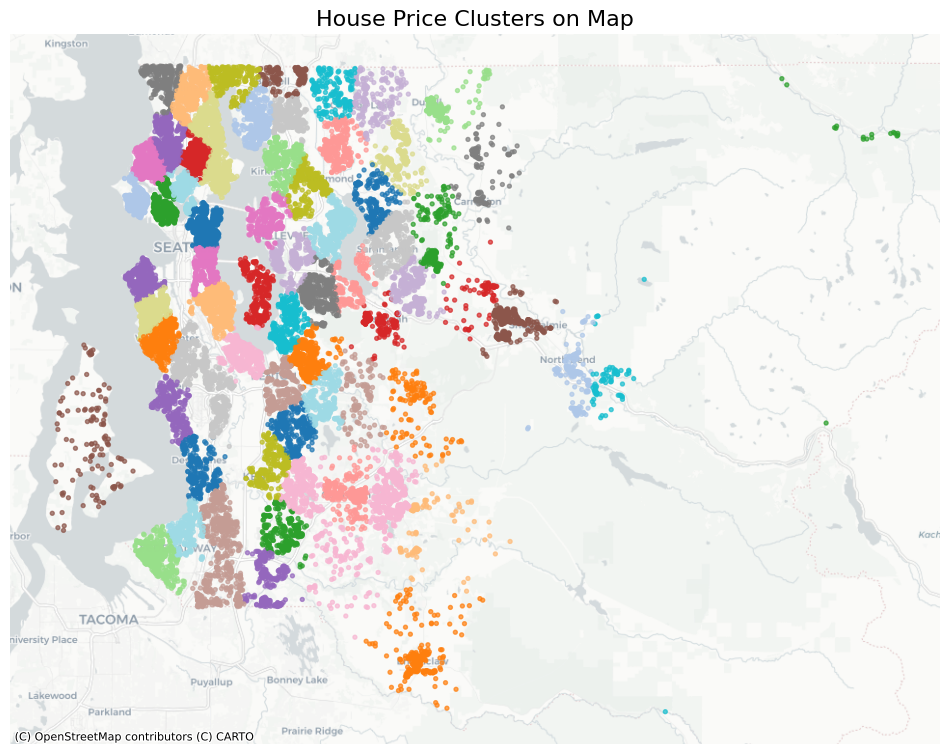

In [309]:
# 1. Create GeoDataFrame from lat/long
gdf = gpd.GeoDataFrame(
    df_cleaned.copy(),
    geometry=gpd.points_from_xy(df_cleaned["long"], df_cleaned["lat"]),
    crs="EPSG:4326"
)

# 2. Convert to Web Mercator projection (needed for the basemap)
gdf = gdf.to_crs(epsg=3857)

# 3. Plot points + map
fig, ax = plt.subplots(figsize=(12, 10))

gdf.plot(
    ax=ax,
    column="neighborhood_group",
    cmap="tab20",
    markersize=8,
    alpha=0.7,
    legend=False
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_title("House Price Clusters on Map", fontsize=16)
ax.set_axis_off()

plt.show()


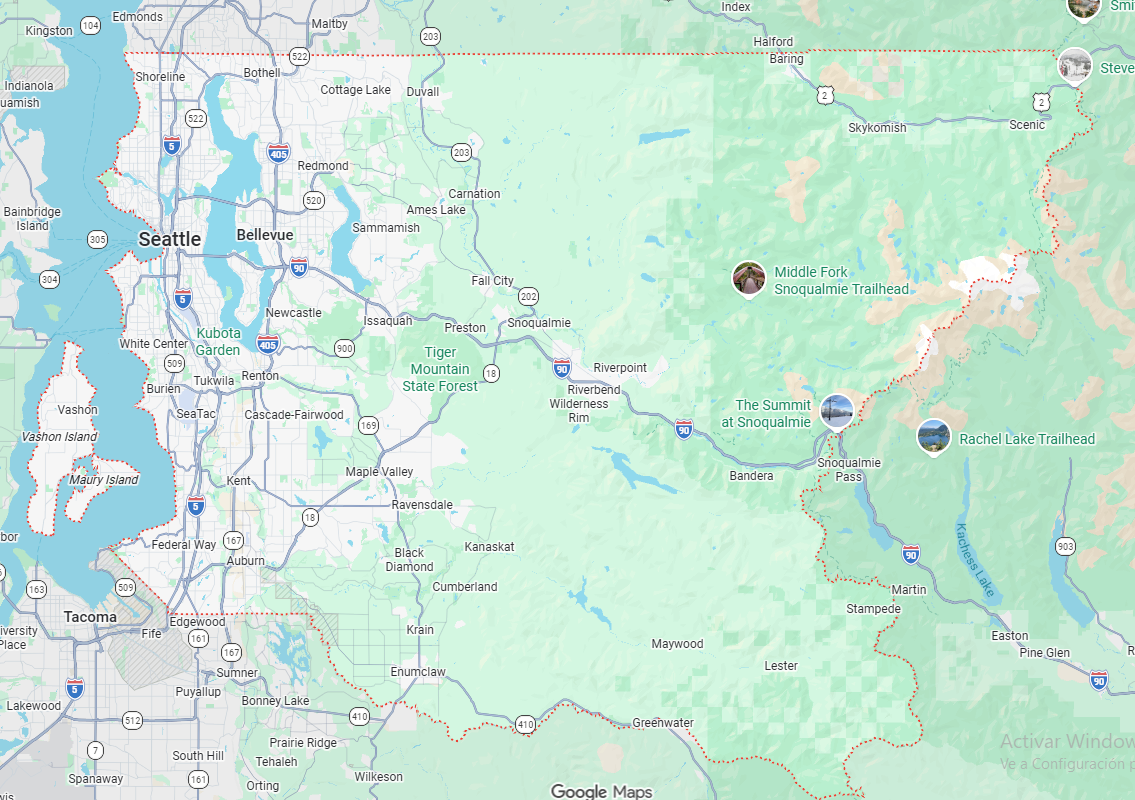

In [310]:
df["zipcode"].value_counts()

zipcode
98103    602
98038    590
98115    583
98052    574
98117    553
        ... 
98102    105
98010    100
98024     81
98148     57
98039     50
Name: count, Length: 70, dtype: int64

In [311]:
# Study the purity of the clusters in terms of zipcodes, to see if the clusters are capturing the geographical information well.
# Using it as another form of correlation between the clusters and the zipcodes.
pd.crosstab(df_cleaned["zipcode"], df_cleaned["neighborhood_group"])

ct = pd.crosstab(df_cleaned["zipcode"], df_cleaned["neighborhood_group"])
purity_by_zipcode = ct.max(axis=1) / ct.sum(axis=1)
purity_by_zipcode.sort_values(ascending=False)

""" The average purity score (~0.72) indicates that zipcode partially aligns with geographic clusters,
 but does not fully capture the underlying spatial structure. KMeans clustering reveals intra-zipcode 
 variation that is lost when using zipcode as a feature. """

print(round(purity_by_zipcode.mean(), 2))

0.72


In [312]:


# -----------------------------------
# 1. Ensure correct data types
# -----------------------------------
df_compare = df_cleaned.copy()

df_compare["zipcode"] = df_compare["zipcode"].astype(str)
df_compare["neighborhood_group"] = df_compare["neighborhood_group"].astype(str)

y = df_compare["price"]

# -----------------------------------
# 2. Dataset using only ZIPCODE
# -----------------------------------
X_zip = pd.get_dummies(df_compare[["zipcode"]], drop_first=True)

X_train_zip, X_test_zip, y_train, y_test = train_test_split(
    X_zip, y, test_size=0.2, random_state=42
)

model_zip = LinearRegression()
model_zip.fit(X_train_zip, y_train)

y_pred_zip = model_zip.predict(X_test_zip)

r2_zip = r2_score(y_test, y_pred_zip)
rmse_zip = np.sqrt(mean_squared_error(y_test, y_pred_zip))

# -----------------------------------
# 3. Dataset using only GEO CLUSTERS
# -----------------------------------
X_geo = pd.get_dummies(df_compare[["neighborhood_group"]], drop_first=True)

X_train_geo, X_test_geo, y_train, y_test = train_test_split(
    X_geo, y, test_size=0.2, random_state=42
)

model_geo = LinearRegression()
model_geo.fit(X_train_geo, y_train)

y_pred_geo = model_geo.predict(X_test_geo)

r2_geo = r2_score(y_test, y_pred_geo)
rmse_geo = np.sqrt(mean_squared_error(y_test, y_pred_geo))

# -----------------------------------
# 4. Comparison
# -----------------------------------
results = pd.DataFrame({
    "model": ["zipcode", "geo_cluster"],
    "R2": [r2_zip, r2_geo],
    "RMSE": [rmse_zip, rmse_geo]
})

print(results)


         model        R2           RMSE
0      zipcode  0.390842  299986.539109
1  geo_cluster  0.359268  307662.825327


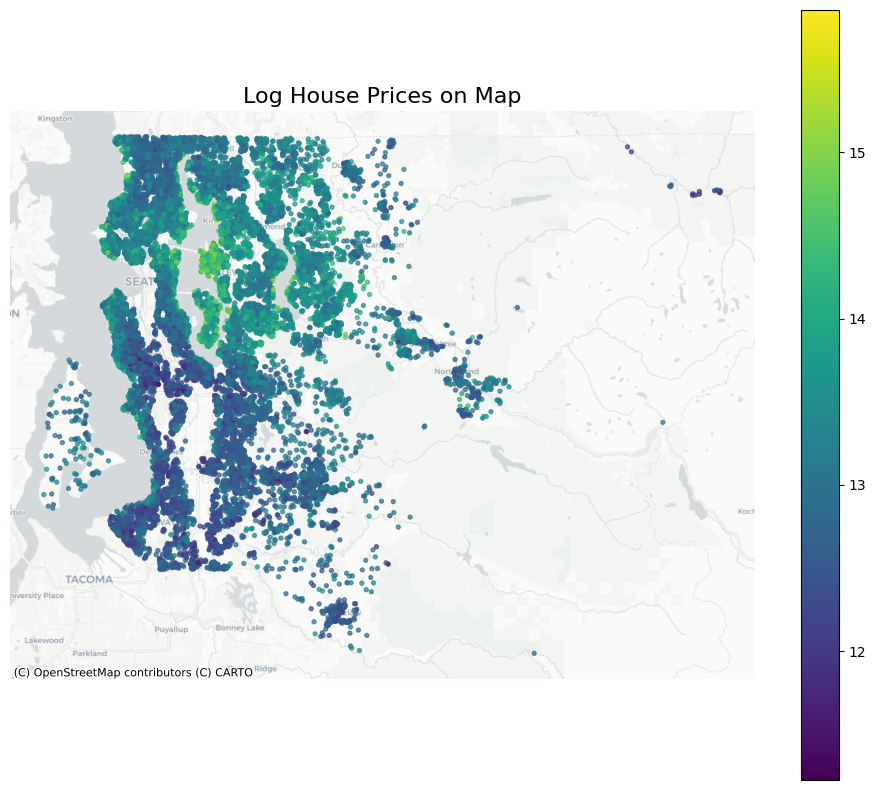

In [313]:
# GEOSPACIAL PRICE MAP

# Create GeoDataFrame from lat/long
gdf = gpd.GeoDataFrame(
    df_cleaned.copy(),
    geometry=gpd.points_from_xy(df_cleaned["long"], df_cleaned["lat"]),
    crs="EPSG:4326"
)

# Convert to Web Mercator projection for basemap
gdf = gdf.to_crs(epsg=3857)

# Plot points colored by log(price) for better representation of skewed distribution
fig, ax = plt.subplots(figsize=(12, 10))

gdf.plot(
    ax=ax,
    column="price_log",
    cmap="viridis",
    markersize=8,
    alpha=0.7,
    legend=True,
    vmin=df_cleaned["price_log"].min(),
    vmax=df_cleaned["price_log"].max()
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_title("Log House Prices on Map", fontsize=16)
ax.set_axis_off()

plt.show()


In [314]:
X = df_cleaned[["lat", "long"]]
y = df_cleaned["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("R2 lat/long RF:", r2_score(y_test, y_pred))



R2 lat/long RF: 0.5833040661124538


## DATA PROCESSING

In [315]:
# One-Hot Encoding the yr_renovated (1 -> YES and 0 -> NO)
df_cleaned["is_renovated"] = df_cleaned["yr_renovated"].apply(lambda x: 1 if x>0 else 0)


In [316]:
# Calculating the age of the houses, dates when it was sold - date of built
df_cleaned["house_age"] = df_cleaned["date"].dt.year - df_cleaned["yr_built"]
df_cleaned["house_age_renovated"] = df_cleaned["date"].dt.year - df_cleaned["yr_renovated"]

In [317]:
# One-Hot Encoding the zipcode
"""
COMMENTING OUT (NO 1-HOT-ENCODING  )
df_cleaned = pd.get_dummies(df_cleaned, columns=["zipcode"])
"""


'\nCOMMENTING OUT (NO 1-HOT-ENCODING  )\ndf_cleaned = pd.get_dummies(df_cleaned, columns=["zipcode"])\n'

In [318]:
# linear correlation between price and date (year)
df_cleaned["price"].corr((df_cleaned["date"]).dt.year)

np.float64(0.0036563843877994062)

In [319]:
df_cleaned["sqft_price"]=df_cleaned["price"] / df_cleaned["sqft_living"]

# We get the mean of the price per square foot to have a better understanding of the price distribution and to be able to compare it with other houses in the same area or with similar characteristics.
df_cleaned["sqft_price"].mean()

np.float64(264.1610455723079)

In [320]:
df_cleaned.drop(columns=["yr_built", "yr_renovated", "date_only", "sqft_price"], inplace=True)

In [321]:
df_cleaned.keys()

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'zipcode', 'lat', 'long', 'sqft_living15',
       'sqft_lot15', 'price_log', 'season', 'dist_to_center',
       'neighborhood_group', 'is_renovated', 'house_age',
       'house_age_renovated'],
      dtype='str')

In [322]:
dropped_columns=["season","neighborhood_group","dist_to_center"]


# HAPPY MONKEY MODELLING

## DEFINING TARGET & FEATURES

In [323]:
df_model=df_cleaned.drop(columns=dropped_columns)
"""
COMMENTING OUT THE ZIPCODE DROP (NO 1-HOT-ENCODING  )
df_model=df_model.drop(columns=df_model.columns[df_model.columns.str.contains("zip")])
"""
print(df_model.keys())


target="price_log"

"""
DROPPING LATER
df_model.drop(columns="price_log", inplace=True)

"""


Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'zipcode', 'lat', 'long', 'sqft_living15',
       'sqft_lot15', 'price_log', 'is_renovated', 'house_age',
       'house_age_renovated'],
      dtype='str')


'\nDROPPING LATER\ndf_model.drop(columns="price_log", inplace=True)\n\n'

copy from here

In [324]:
num_features = [ 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'sqft_above', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'house_age', 'house_age_renovated']
cat_features = [ 'waterfront', 'view', 'condition', 'grade', 'is_renovated' ]

df_model_cat=df_model.drop(columns=num_features)
df_model_num=df_model[num_features]

In [325]:
df_model_cat.keys()


Index(['date', 'price', 'waterfront', 'view', 'condition', 'grade', 'zipcode',
       'price_log', 'is_renovated'],
      dtype='str')

In [326]:
len(df_model_cat.keys()) == len(cat_features)

False

## TRAIN/TEST SPLIT

In [327]:
# Sort by date so the oldest observations go first
df_model = df_model.sort_values("date").copy()

# Extract date-based features to help the model capture temporal patterns
df_model["year"] = df_model["date"].dt.year
df_model["month"] = df_model["date"].dt.month
df_model["day"] = df_model["date"].dt.day
df_model["dayofweek"] = df_model["date"].dt.dayofweek
df_model["quarter"] = df_model["date"].dt.quarter

# Time-based split: older data for training, newer data for testing
train_size = int(len(df_model) * 0.8)
train_df = df_model.iloc[:train_size].copy()
test_df = df_model.iloc[train_size:].copy()

# Create spatial interaction features from latitude and longitude
train_df["lat_long"] = train_df["lat"] * train_df["long"]
test_df["lat_long"] = test_df["lat"] * test_df["long"]

train_df["lat_sq"] = train_df["lat"] ** 2
test_df["lat_sq"] = test_df["lat"] ** 2

train_df["long_sq"] = train_df["long"] ** 2
test_df["long_sq"] = test_df["long"] ** 2

# Target encoding for zipcode using training data only
zipcode_mean = train_df.groupby("zipcode")[target].mean()


train_df["zipcode_te"] = train_df["zipcode"].map(zipcode_mean)
test_df["zipcode_te"] = test_df["zipcode"].map(zipcode_mean)

# Fill unseen zipcodes in test set with the global mean price from training data
global_mean = train_df[target].mean()
test_df["zipcode_te"] = test_df["zipcode_te"].fillna(global_mean)

# Define features and target
X_train = train_df.drop(columns=["price", "date", target])
y_train = train_df[target]

X_test = test_df.drop(columns=["price", "date", target])
y_test = test_df[target]

In [328]:
# dropping zipcode column after target encoding
X_train = X_train.drop(columns=["zipcode"])
X_test = X_test.drop(columns=["zipcode"])

In [329]:
# FEATURES
print(X_train.keys(),X_train.shape[1])

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15',
       'is_renovated', 'house_age', 'house_age_renovated', 'year', 'month',
       'day', 'dayofweek', 'quarter', 'lat_long', 'lat_sq', 'long_sq',
       'zipcode_te'],
      dtype='str') 27


## MODEL DICTIONARY

In [330]:


models = {
    # Linear baselines
    "linear_regression": LinearRegression(),


    # Single tree
    "decision_tree": DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=30,
        min_samples_split=40,
        random_state=42
    ),

    # Bagging / tree ensembles
    "random_forest": RandomForestRegressor(
        n_estimators=600,
        max_depth=16,
        min_samples_leaf=3,
        min_samples_split=8,
        max_features="sqrt",
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ),
    "extra_trees": ExtraTreesRegressor(
        n_estimators=600,
        max_depth=16,
        min_samples_leaf=3,
        min_samples_split=8,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ),

    # Boosting
    "gradient_boosting": GradientBoostingRegressor(
        n_estimators=800,
        learning_rate=0.02,
        max_depth=3,
        min_samples_leaf=8,
        subsample=0.8,
        random_state=42
    ),
    "adaboost": AdaBoostRegressor(
        n_estimators=300,
        learning_rate=0.03,
        random_state=42
    ),
    "lightgbm": LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.02,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=15,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.2,
        reg_lambda=0.2,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),


}


In [331]:
scaled_models = {
    "knn_scaled": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=10, weights="distance"))
    ]),
    "svr_rbf_scaled": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=10.0, epsilon=0.1))
    ]),
    "ridge_scaled": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=3.0))
    ]),
    "lasso_scaled": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.001, max_iter=10000))
    ]),
    "elastic_net_scaled": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000))
    ])
}

In [332]:
all_models = {**models, **scaled_models}

## MODEL EVALUATION FUNCTION

In [338]:
def evaluate_models_ts(models, X, y, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    results = []

    for name, model in models.items():
        mae_scores = []
        rmse_scores = []
        r2_scores = []
        mape_scores = []

        for train_idx, val_idx in tscv.split(X):
            X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
            y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

            # Train
            model.fit(X_train_fold, y_train_fold)

            # Predict in log scale
            y_pred_log = model.predict(X_val_fold)

            # Safe transformation to real price scale (avoid overflow)
            y_pred = np.exp(np.clip(y_pred_log, -20, 20))
            y_real = np.exp(y_val_fold)

            # Metrics in real scale (€)
            mae_scores.append(mean_absolute_error(y_real, y_pred))
            rmse_scores.append(np.sqrt(mean_squared_error(y_real, y_pred)))
            mape_scores.append(np.mean(np.abs((y_real - y_pred) / y_real)) * 100)
            r2_scores.append(r2_score(y_real, y_pred))

        results.append({
            "model": name,
            "mae_mean": np.mean(mae_scores),
            "rmse_mean": np.mean(rmse_scores),
            "mape_mean": np.mean(mape_scores),
            "r2_mean": np.mean(r2_scores)
        })

    return pd.DataFrame(results).sort_values("mape_mean", ascending=True)

In [339]:
print("Any NaN in y_train?", y_train.isna().any())
print("Any inf in y_train?", np.isinf(y_train).any())
print("Max y_train:", y_train.max())
print("Min y_train:", y_train.min())

Any NaN in y_train? False
Any inf in y_train? False
Max y_train: 15.856730886823913
Min y_train: 11.225243392518447


## MODEL SELECTION

In [340]:
results_ts = evaluate_models_ts(models, X_train, y_train, n_splits=5)
print(results_ts)

               model       mae_mean      rmse_mean  mape_mean   r2_mean
6           lightgbm   63177.916265  120224.006638  11.786001  0.891527
4  gradient_boosting   66432.781537  123491.775243  12.324635  0.885728
2      random_forest   70763.644647  151215.527235  12.521633  0.828518
3        extra_trees   75205.105928  161103.107251  13.200243  0.805318
0  linear_regression   79451.215270  148916.081270  14.660043  0.833006
1      decision_tree   93360.731228  186065.792153  16.575758  0.739952
5           adaboost  102989.038878  201366.706907  18.533049  0.696265


In [341]:
top_models = results_ts.head(3)["model"].tolist()
print(top_models)

['lightgbm', 'gradient_boosting', 'random_forest']


## TUNING LGBM

In [342]:
param_dist = {
    "n_estimators": [500, 1000, 2000],
    "learning_rate": [0.01, 0.02, 0.05],
    "num_leaves": [20, 31, 50],
    "min_child_samples": [10, 20, 40],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [0, 0.1, 0.5]
}

lgbm = LGBMRegressor(
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=25,
    scoring="r2",
    cv=TimeSeriesSplit(n_splits=5),
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_lgbm = search.best_estimator_

print("Best params:", search.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'num_leaves': 20, 'n_estimators': 2000, 'min_child_samples': 10, 'learning_rate': 0.02, 'colsample_bytree': 0.8}


In [353]:
# Predict in log scale
y_pred_log = best_lgbm.predict(X_test)

# Convert to real price scale
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_test)

# Metrics in real price (€)
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("Final model performance (real price scale):")
print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)

Final model performance (real price scale):
R2: 0.8941769333756403
RMSE: 119572.23430785933
MAE: 68866.0597003187
MAPE: 12.218845878731708


In [354]:
lgbm_pred = best_lgbm.predict(X_test)
rf_pred = models["random_forest"].fit(X_train, y_train).predict(X_test)
gb_pred = models["gradient_boosting"].fit(X_train, y_train).predict(X_test)

final_pred = (
    0.6 * lgbm_pred +
    0.25 * gb_pred +
    0.15 * rf_pred
)

print("Ensemble R2:", r2_score(y_test, final_pred))

Ensemble R2: 0.887177256860803


In [355]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_lgbm.feature_importances_
}).sort_values("importance", ascending=False)

print(feature_importance.head(15))

          feature  importance
16      house_age        3245
12           long        3030
11            lat        2918
2     sqft_living        2876
3        sqft_lot        2791
13  sqft_living15        2511
23       lat_long        2450
26     zipcode_te        2224
9      sqft_above        2166
14     sqft_lot15        2134
20            day        1482
25        long_sq        1308
10  sqft_basement        1142
8           grade        1108
19          month        1011


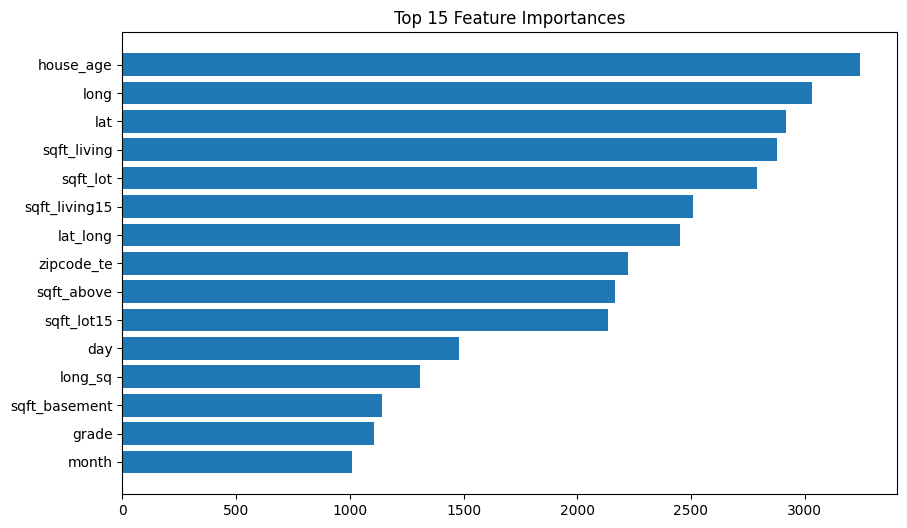

In [356]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance["feature"][:15][::-1],
         feature_importance["importance"][:15][::-1])
plt.title("Top 15 Feature Importances")
plt.show()

In [357]:
explainer = shap.Explainer(best_lgbm, X_train)
shap_values = explainer(X_test)

100%|===================| 4312/4322 [02:35<00:00]        

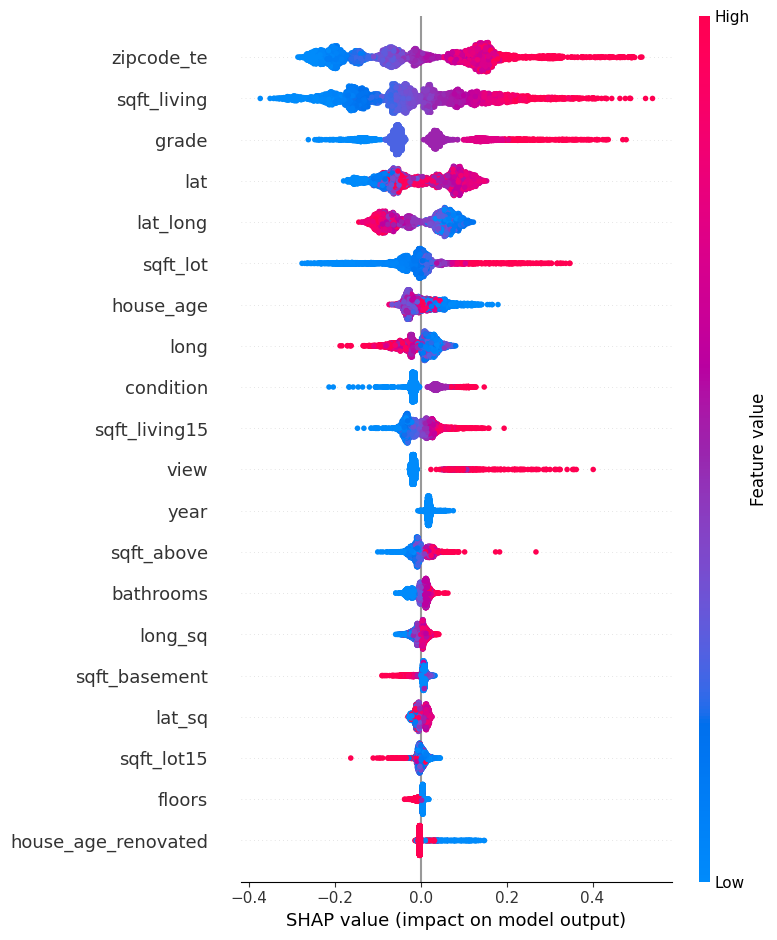

In [358]:
shap.summary_plot(shap_values, X_test)

## IMPORTANCE BY FEATURES

In [359]:
feature_groups = {
    
    # Location-related features
    "location": [
        "lat", "long", "lat_long", "lat_sq", "long_sq", "zipcode_te"
    ],
    
    # Size-related features (main drivers of price)
    "size": [
        "sqft_living", "sqft_lot", "sqft_above", "sqft_basement",
        "sqft_living15", "sqft_lot15"
    ],
    
    # Structural characteristics of the property
    "structure": [
        "bedrooms", "bathrooms", "floors"
    ],
    
    # Quality and desirability features
    "quality": [
        "condition", "grade", "view", "waterfront"
    ],
    
    # Age and renovation-related features
    "age": [
        "house_age", "house_age_renovated", "is_renovated"
    ],
    
    # Temporal features (market dynamics and seasonality)
    "temporal": [
        "year", "month", "day", "dayofweek", "quarter"
    ]
}

feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_lgbm.feature_importances_
})

In [360]:
group_importance = {}

for group, features in feature_groups.items():
    importance_sum = feature_importance_df[
        feature_importance_df["feature"].isin(features)
    ]["importance"].sum()
    
    group_importance[group] = importance_sum

group_importance_df = pd.DataFrame(
    list(group_importance.items()),
    columns=["group", "importance"]
).sort_values("importance", ascending=False)

In [361]:
group_importance_df["importance_pct"] = (
    group_importance_df["importance"] / group_importance_df["importance"].sum()
) * 100

<Axes: ylabel='group'>

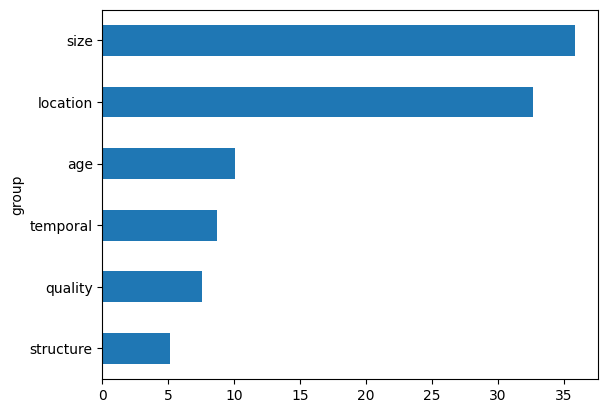

In [362]:
group_importance_df.sort_values("importance_pct").plot(
    x="group",
    y="importance_pct",
    kind="barh",
    legend=False
)

In [ ]:
df_650k_plus = df_model[df_model["price"] >= 650000].copy()

paste from here